# Temperature sampling

**Insight:** sample from $\mathrm{softmax}(z / T)$. Small $T$ stretches logit gaps (near-greedy); large $T$ flattens toward uniform. Clamp tiny $T$ to argmax.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(z):
    z = np.asarray(z, dtype=np.float64)
    z = z - np.max(z)
    e = np.exp(z)
    return e / e.sum()

def sample(z, T, rng):
    z = np.asarray(z, dtype=np.float64)
    if T <= 1e-8:
        return int(np.argmax(z))
    return int(rng.choice(len(z), p=softmax(z / T)))

z = np.array([1.0, 2.0, 3.0])


## How temperature reshapes the distribution

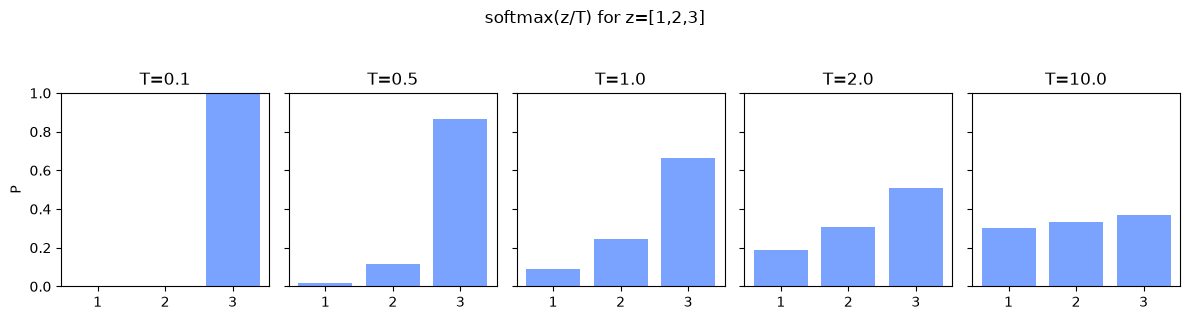

In [2]:
Ts = [0.1, 0.5, 1.0, 2.0, 10.0]
fig, axes = plt.subplots(1, len(Ts), figsize=(12, 3), sharey=True)
x = np.arange(len(z))
for ax, T in zip(axes, Ts):
    p = softmax(z / T)
    ax.bar(x, p, color='#7aa2ff')
    ax.set_title(f'T={T}')
    ax.set_xticks(x)
    ax.set_xticklabels(['1','2','3'])
    ax.set_ylim(0, 1)
axes[0].set_ylabel('P')
fig.suptitle('softmax(z/T) for z=[1,2,3]', y=1.05)
plt.tight_layout()
plt.show()


## Empirical sample frequencies vs theory (T=1)

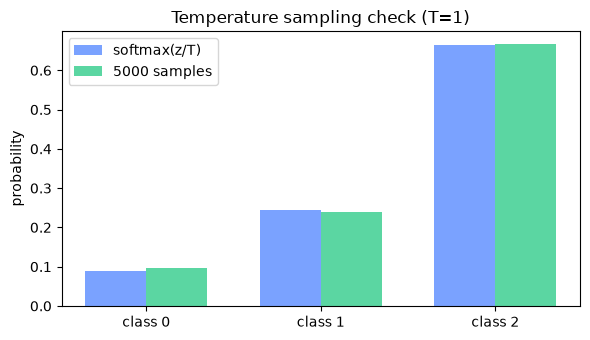

theory [0.09003057 0.24472847 0.66524096]
freqs  [0.0954 0.2386 0.666 ]


In [3]:
rng = np.random.default_rng(0)
T = 1.0
counts = np.zeros(len(z))
N = 5000
for _ in range(N):
    counts[sample(z, T, rng)] += 1
freqs = counts / N
theory = softmax(z / T)

fig, ax = plt.subplots(figsize=(6, 3.5))
w = 0.35
ax.bar(np.arange(len(z)) - w/2, theory, w, label='softmax(z/T)', color='#7aa2ff')
ax.bar(np.arange(len(z)) + w/2, freqs, w, label=f'{N} samples', color='#5bd6a2')
ax.set_xticks(range(len(z)))
ax.set_xticklabels([f'class {i}' for i in range(len(z))])
ax.set_ylabel('probability')
ax.legend()
ax.set_title('Temperature sampling check (T=1)')
plt.tight_layout()
plt.show()
print('theory', theory)
print('freqs ', freqs)
